# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Njeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

### 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. **Department of Refugee Services (DRS)**: The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. **United Nations High Commissioner for Refugees (UNHCR)**: Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. **World Food Programme (WFP)**: Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. **Kenya Red Cross Society (KRCS)**: Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

### 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

### 3. Project Objectives

#### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

#### 3.2 Specific Objectives


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

### 4. Data Understanding


The dataset used for this project is the Kenya Refugee and Asylum Population Dataset, obtained from the Humanitarian Data Exchange (HDX) platform.The dataset contains historical records of displaced populations hosted in Kenya and provides detailed demographic information necessary for forecasting refugee population trends and supporting humanitarian resource planning.

The dataset covers a 25-year period from 2001 to 2025, containing 27,664 records and 15 variables. Each record represents a population observation reported for a specific period, location, population category, gender, and age group.

The dataset includes four main population groups:

1. **Refugees (REF)**: Individuals who have been recognized as refugees and require international protection.
2. **Asylum Seekers (ASY)**: Individuals who have applied for refugee status and are awaiting determination.
3. **Host Community (HST)**: Members of the local population affected by refugee presence and humanitarian operations.
4. **Others of Concern (OOC)**: Individuals who require humanitarian assistance but do not fall under the refugee or asylum seeker categories.

The main target variable for this project is:

**Population**: The recorded number of individuals within each demographic category. 

**Key predictor variables**

| Column | Description |
|---|---|
| reference_period_start / end | Reporting period boundaries |
| asylum_location_code | Country where asylum is provided |
| origin_location_code | Country of origin of displaced population |
| population_group | Refugee population category |
| gender | Gender category (male/female) |
| age_range | Age cohort category |
| min_age / max_age | Age boundaries of the cohort |
| population | Number of individuals recorded (target) |

he dataset is well suited to this project because it contains long-term historical observations, demographic breakdowns, and population movement patterns required for machine learning forecasting.

#### 4.1 Loading of Data  and relevant Libraries

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


#### 4.2 Data Overview

In [3]:
#total rows and columns
df.shape

(27664, 14)

In [4]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*Dataset has 27,664 rows and 15 columns*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   origin_location_code    27664 non-null  object 
 1   origin_has_hrp          27664 non-null  bool   
 2   origin_in_gho           27664 non-null  bool   
 3   asylum_location_code    27664 non-null  object 
 4   asylum_has_hrp          27664 non-null  bool   
 5   asylum_in_gho           27664 non-null  bool   
 6   population_group        27664 non-null  object 
 7   gender                  27664 non-null  object 
 8   age_range               27664 non-null  object 
 9   min_age                 21280 non-null  float64
 10  max_age                 17024 non-null  float64
 11  population              27664 non-null  int64  
 12  reference_period_start  27664 non-null  object 
 13  reference_period_end    27664 non-null  object 
dtypes: bool(4), float64(2), int64(1), obje

The dataset contains a combination of categorical, numerical, and date-based variables.
An assessment of missing values shows that no missing values are present across the dataset variables.

In [6]:
df.describe()

,min_age,max_age,population
count,21280.00000,17024.00000,27664.000000
mean,19.00000,22.75000,1409.757591
std,21.39209,21.42929,13881.284560
min,0.00000,4.00000,0.000000
25%,5.00000,9.25000,0.000000
50%,12.00000,14.00000,0.000000
75%,18.00000,27.50000,17.000000
max,60.00000,59.00000,517666.000000


The descriptive statistic show that the population variable has a highly uneven distribution, ranging from **0 to 517,666 individuals** across 27,664 observations. The mean population of approximately **1,410** compared to a median of **0** indicates that many records represent small or zero population groups, while a few observations contain very large refugee populations.

This pattern is expected in humanitarian datasets because records are highly disaggregated by country of origin, age, gender, and population group. Zero values may represent valid cases where no individuals were recorded for a specific category and period, rather than missing data. Therefore, they will be retained and considered during modeling. The variation in population sizes highlights the need for machine learning approaches capable of capturing both stable population trends and sudden displacement changes.


### 5. Data Cleaning

Data cleaning was conducted to improve data quality and ensure that the dataset was suitable for exploratory analysis and machine learning forecasting. The cleaning process focused on selecting relevant records, removing duplicate representations, validating data completeness, correcting data types, and investigating unusual population values.

#### 5.1 Filtering relevant records

In [7]:
#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12.0,17.0,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18.0,59.0,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60.0,NaN,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,NaN,NaN,8,2025-01-01,2025-12-31


The dataset was first filtered to include only records where the asylum location was Kenya. This ensured that the analysis focused specifically on refugee and asylum populations hosted within Kenya, aligning with the project's objective of forecasting humanitarian needs in the country.

#### 5.2 Checking Missing Values and Duplicates

The dataset was assessed for missing values and duplicate records. The analysis showed that there were no missing values across the variables, indicating that the dataset was complete and did not require missing value imputation. Duplicate records were also checked to ensure that repeated observations would not affect population estimates or model performance.

In [8]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code         0
origin_has_hrp               0
origin_in_gho                0
asylum_location_code         0
asylum_has_hrp               0
asylum_in_gho                0
population_group             0
gender                       0
age_range                    0
min_age                   2562
max_age                   4270
population                   0
reference_period_start       0
reference_period_end         0
dtype: int64


Duplicate : 0


#### 5.3 Handling Aggregated Categories

The dataset contained aggregated categories represented as "all" in the gender and age range variables. These categories were reviewed to determine whether they would affect population analysis.




In [9]:
# Display the unique gender categories in the dataset
df['gender'].unique()

array(['f', 'm', 'all'], dtype=object)

In [10]:
#we noticed that the all column was an addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The "all" gender category was removed because it represents the combined total of male and female populations. Keeping this category alongside the individual male and female records would result in duplicate population counts and inflate population estimates.

In [11]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

In [12]:
#Checking the frequency distribution of the age range category
df['age_range'].value_counts()

age_range
0-4      1708
5-11     1708
12-17    1708
18-59    1708
60+      1708
all      1708
Name: count, dtype: int64

The dataset contained five defined age cohorts (0–4, 5–11, 12–17, 18–59, and 60+) as well as an aggregated `"all"` category.

In [13]:
# Drop the aggregated 'all' age category for the same reason as gender
df = df[df['age_range'] != 'all']
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

The "all" category was removed because it represents an aggregated population total rather than a distinct age cohort. Including it alongside individual age groups could introduce overlapping population information and affect age-specific analysis and forecasting.

The 60+ category was intentionally left without an artificial maximum age, since it represents an open-ended age group; introducing a fixed upper limit would create an unsupported assumption about elderly population estimates.

#### 5.4 Validating Population Values

The population variable was examined to understand its distribution and identify potential data quality issues. The analysis showed that population values ranged from zero to very large population counts. A significant number of records contained zero population values.

Further investigation showed that zero values occurred across different: population groups,gender categories,and age ranges.



In [14]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

In [15]:
# Display the unique population group categories in the dataset
df['population_group'].unique()

array(['ASY', 'REF', 'HST', 'OOC'], dtype=object)

In [16]:
# Where do the zero-population records come from?
print("Zero population by group:\n", df[df['population'] == 0]['population_group'].value_counts())
print("\nZero population by gender:\n", df[df['population'] == 0]['gender'].value_counts())
print("\nZero population by age range:\n", df[df['population'] == 0]['age_range'].value_counts())
print(f"\nShare of records with zero population: {(df['population'] == 0).mean()*100:.1f}%")

Zero population by group:
 population_group
ASY    2084
REF    1498
OOC     140
HST      60
Name: count, dtype: int64

Zero population by gender:
 gender
f    1971
m    1811
Name: count, dtype: int64

Zero population by age range:
 age_range
60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
Name: count, dtype: int64

Share of records with zero population: 44.3%


Approximately 44% of observations have zero population counts. This is expected in a highly disaggregated refugee dataset where many demographic combinations may have no recorded individuals during a reporting period. Since zeros occur across multiple groups and are not associated with a specific data quality issue, they were retained as valid observations.

Retaining zero values allows the forecasting model to learn both population growth patterns and periods of low or absent population presence, improving its ability to support realistic humanitarian planning.

#### 5.5 Converting Date Variables

In [17]:
# Convert reporting period to datetime and derive a single 'year' feature
df['reference_period_start'] = pd.to_datetime(df['reference_period_start'])
df['reference_period_end'] = pd.to_datetime(df['reference_period_end'])

df['year'] = df['reference_period_start'].dt.year
df.drop(columns=['reference_period_start', 'reference_period_end'], inplace=True)


#### 5.6 Handling Extreme Population Values

The population distribution was reviewed using  boxplots.

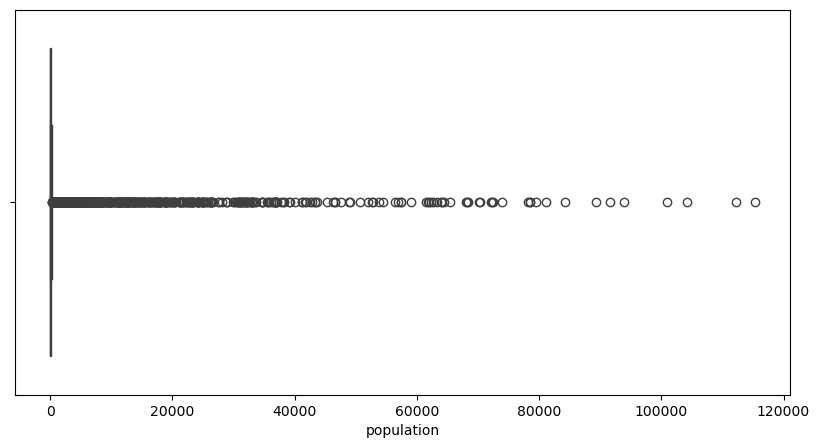

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['population'])
plt.show()

The variable showed a highly right-skewed distribution, with a small number of very large population counts. These extreme values were retained because they represent genuine large refugee populations and are important for humanitarian resource planning. Removing them would reduce the model's ability to capture large-scale displacement events.

#### 5.7 Final Validation of data

In [19]:
print(df.shape)
df.info()
df.head()

(8540, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 27661
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   origin_location_code  8540 non-null   object 
 1   origin_has_hrp        8540 non-null   bool   
 2   origin_in_gho         8540 non-null   bool   
 3   asylum_location_code  8540 non-null   object 
 4   asylum_has_hrp        8540 non-null   bool   
 5   asylum_in_gho         8540 non-null   bool   
 6   population_group      8540 non-null   object 
 7   gender                8540 non-null   object 
 8   age_range             8540 non-null   object 
 9   min_age               8540 non-null   float64
 10  max_age               6832 non-null   float64
 11  population            8540 non-null   int64  
 12  year                  8540 non-null   int32  
dtypes: bool(4), float64(2), int32(1), int64(1), object(5)
memory usage: 667.2+ KB


,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


Zero population values are observed across all age groups, with the largest number occurring among children aged 0–4 years. Since the zeros are spread throughout the age categories rather than concentrated in a single group, they are more likely to represent valid observations than systematic data errors. The zero values will be retained because there is no evidence that they are caused by age-specific reporting problems.

**6. EXPLORATORY DATA ANALYSIS**

**UNIVARIATE ANALYSIS**

All variables in the dataset except population are categorical and repeat throughout the dataset with equal frequency, so univariate counts add limited insight. The remainder of the EDA therefore focuses on bivariate and multivariate analysis, which reveal how population varies across categories.

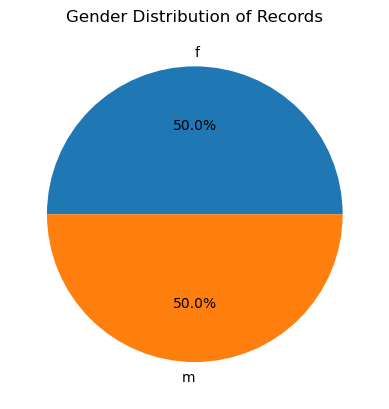

In [20]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution of Records")
plt.ylabel("")
plt.show()

The graph shows that there is a balanced disttribution of all the age ranges as represented in the dataset.

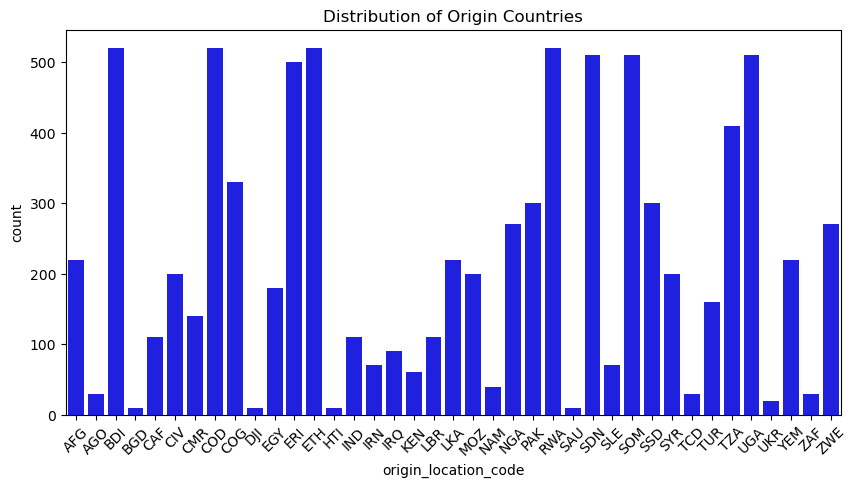

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="origin_location_code",
    order=sorted(df["origin_location_code"].unique()),
    color='blue'
)

plt.title("Distribution of Origin Countries")
plt.xticks(rotation=45)
plt.show()

The plot shows the representation of different refugee origin countries within the dataset. The number of records varies across countries due to differences in reporting frequency and duration of refugee presence. This provides an understanding of data coverage across origin countries before further population analysis.



**BIVARIATE ANALYSIS**

<function matplotlib.pyplot.show(close=None, block=None)>

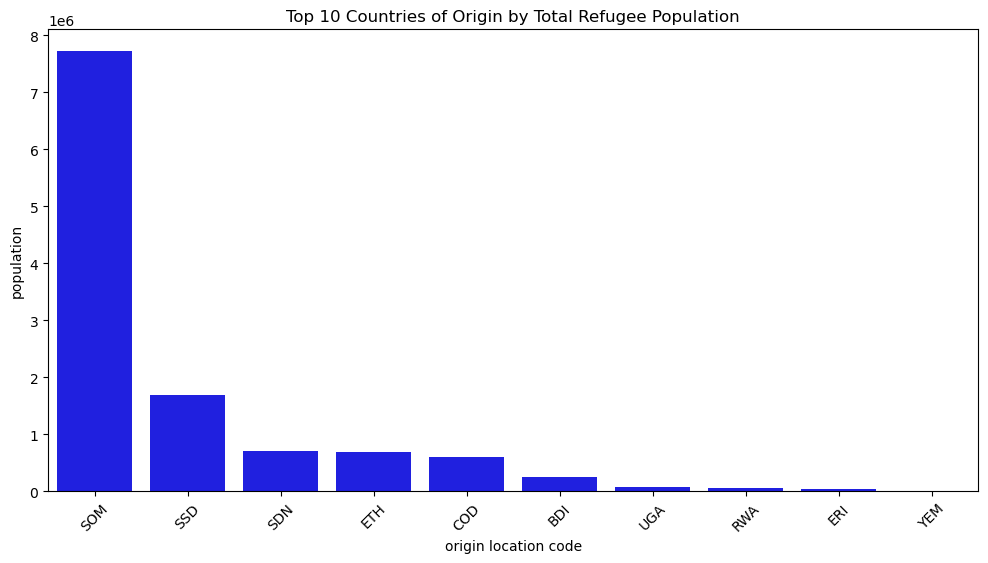

In [22]:
#A graph of countries against the population. This is to show where most refugees have come from across the dataset.

#Grouping origin location codes and finding the total population for each one of them.
country_population = (
    df.groupby('origin_location_code')['population']
        .sum()
        .reset_index()
)

top_10 = (
    country_population
    .sort_values(by = 'population', ascending = False)
    .head(10)
)

#Plotting the bar based on the grouped data above.
plt.figure(figsize=(12,6))

sns.barplot(data=top_10, x= 'origin_location_code', y = 'population', color='blue')

plt.title("Top 10 Countries of Origin by Total Refugee Population")
plt.xlabel("origin location code")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show


**Interepretation of the origin location vs population graph**

Based on the above bar chart, the maximum refugees that end up in Kenya are from Somalia,followed by Southsudan by a very big distance followed by Sudan,Ethiopia and Congo. This is to say that Kenyan refugees comes from the immediate neignbbouring countries rather than countries that involve crossing multiple borders to get to Kenya.

In [23]:
#Running the dataframe for visibility
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


<function matplotlib.pyplot.show(close=None, block=None)>

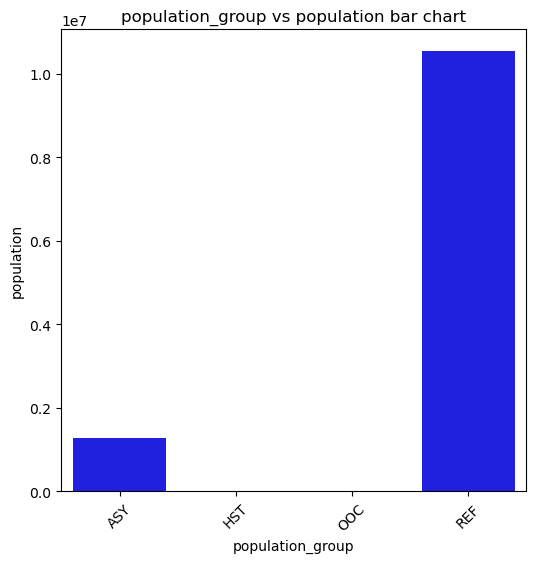

In [24]:
#The plot below is for population group which is either asylum or refugee etc against population

#creating a variable which groups the data by population group and computes the total population of each.
population_g_population = (
    df.groupby('population_group')['population']
        .sum()
        .reset_index()
)

#Plotting the bar graph
plt.figure(figsize=(6,6))

sns.barplot(data=population_g_population, x= 'population_group', y = 'population', color='blue')

plt.title("population_group vs population bar chart")
plt.xlabel("population_group")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show

**Interepretation of the origin location vs population graph**

The bar graph stresses on 2 categories which is Refugee and Asylum. With refugees being the people who receive their official status of being refugees while int heir origin country while asylum seekers receive their official status while already in the destination country.

However it is, the refugees are the majority 10-foled. This is a good indicator for humanitarian organizations in resource planning as most individuals are already identified while they are still in their country of origin. This gives lead time before they arrive in the destination country.

The other 2 categories are for Host Community and Others of Concern. These form a very negligible part of the data and aren't expected to have much impact on the final models.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


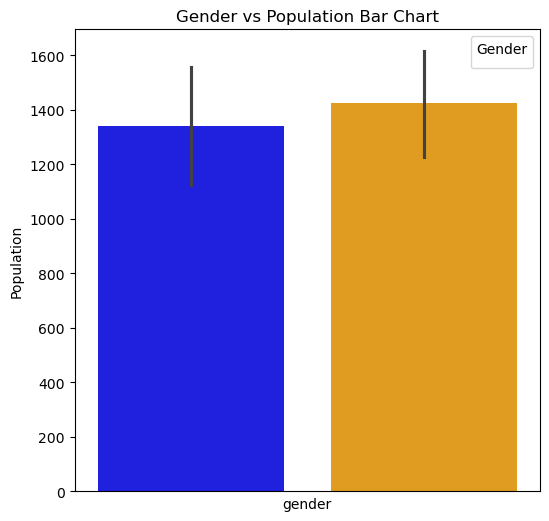

In [25]:
plt.figure(figsize=(6,6))

sns.barplot(
    data=df,
    x='gender',
    y='population',
    hue='gender',
    palette={'m': 'orange', 'f': 'blue'}
)

plt.title("Gender vs Population Bar Chart")
plt.xticks([])
plt.ylabel("Population")
plt.legend(title='Gender',)
plt.show()

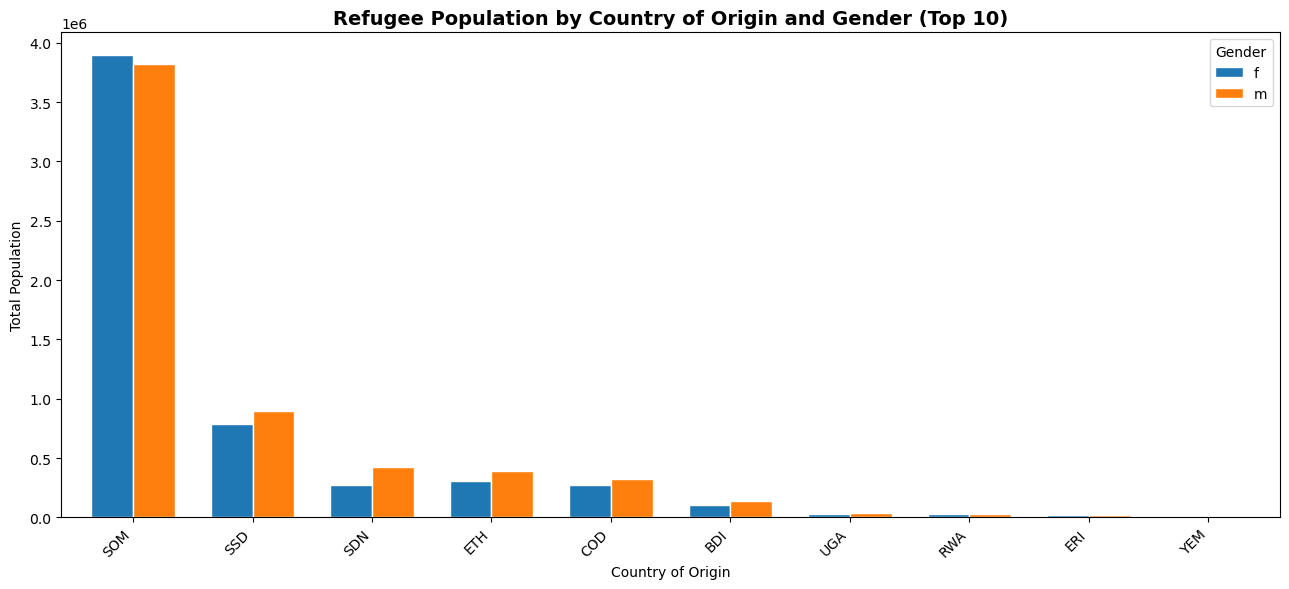

In [26]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

**Interepretation of the above graphs**

The nearly equal proportion of men and women suggests that displacement from the main countries of origin affects both genders at similar rates. For humanitarian planners, this indicates that gender-responsive interventions should receive balanced funding and staffing.

<function matplotlib.pyplot.show(close=None, block=None)>

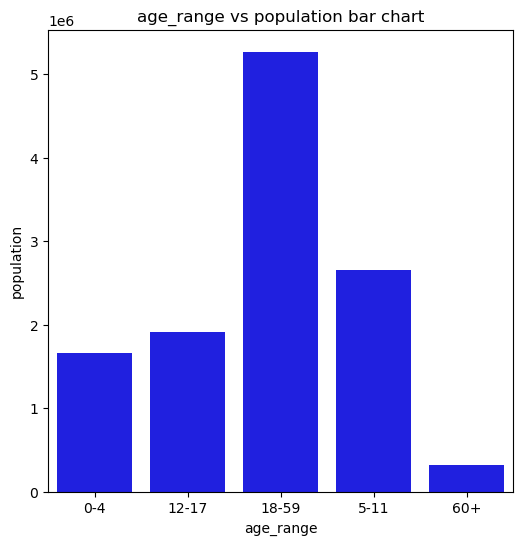

In [27]:
#Plotting a baer chart for age range against population

#Grouping age range and getting the total of population for each category
age_range_population = (
    df.groupby('age_range')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=age_range_population, x= 'age_range', y = 'population', color='blue')

plt.title("age_range vs population bar chart")
plt.xlabel("age_range")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

**Interepretation of the graph**

The 18–59 age group forms the largest share of the population due to its broad age range. Children (0–17) also make up a significant proportion, highlighting the need for education, child protection, and nutrition services. Although the 60+ group is the smallest, it has the greatest healthcare needs. The UNHCR Age, Gender and Diversity (AGD) framework emphasizes planning based on age- and gender-disaggregated data to meet these diverse needs.


<function matplotlib.pyplot.show(close=None, block=None)>

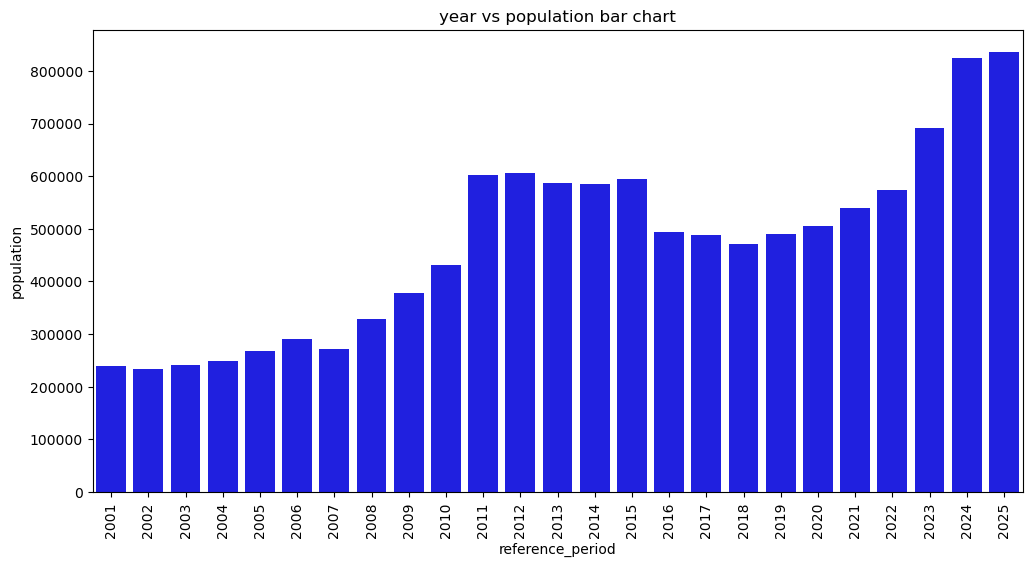

In [28]:
#Plotting a bar chart for the reference years against population

#Grouping the data based on years and then finding the sum of each.
period_population = (
    df.groupby('year')['population']
        .sum()
        .reset_index()
)

#Plotting thebar

plt.figure(figsize=(12,6))

sns.barplot(data=period_population, x= 'year', y = 'population', color='blue')

plt.title("year vs population bar chart")
plt.xlabel("reference_period")
plt.ylabel("population")
plt.xticks(rotation=90)
plt.show

**Interepretation of the graph**

The trend shows three phases: rapid growth (2001–2011), a period of stability and slight decline (2012–2019), and renewed growth from 2020 onward due to escalating regional conflicts. This non-linear pattern demonstrates that simple trend-based forecasting is inadequate, highlighting the need for machine learning models that can better capture complex population dynamics.


**MULTIVARIATE ANALYSIS**

Two variables at a time can only tell you so much. Multivariate analysis looks at three or more simultaneously, surfacing the layered demographic patterns that stay hidden in simpler views.

For humanitarian organizations, understanding how age, gender, country of origin, and population interact is essential for effective resource planning and forecasting.

The four analyses below move from demographic composition to country-gender dynamics to origin dominance to temporal trends, building
a complete picture of Kenya's refugee population structure.


**Age Range, Gender and Population**

### Business Question

How is the refugee population distributed across different age groups and genders?

Understanding the demographic composition of refugee populations can help humanitarian agencies allocate healthcare, education, protection services, and livelihood programs more effectively.

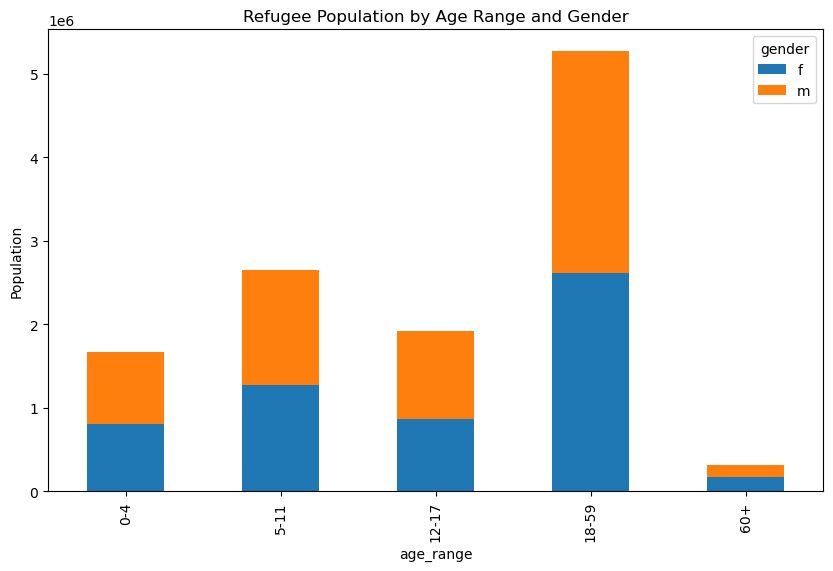

In [29]:
age_gender = pd.pivot_table(
    df,
    values='population',
    index='age_range',
    columns='gender',
    aggfunc='sum'
)
age_order = ['0-4', '5-11', '12-17', '18-59', '60+']
age_gender = age_gender.reindex(age_order)
age_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Refugee Population by Age Range and Gender')
plt.ylabel('Population')
plt.show()

### Observation

The 18–59 working-age group is the largest demographic for both males and females, reflecting that displacement is primarily experienced by adults escaping conflict or persecution. Children aged 0–17 also make up a considerable share of the population, while those aged 60 and above represent the smallest group. Gender distribution remains relatively balanced across all age categories, with neither sex having significant dominance.

### Business Insight

The demographic profile has important planning implications. The large 18–59 population drives demand for livelihood, skills training, and adult mental health services. The sizeable 0–17 population calls for sustained investment in education, nutrition, and child protection. Although the 60+ group is small, it has greater healthcare needs, consistent with the UNHCR Age, Gender and Diversity (AGD) framework. The balanced gender distribution also calls for equitable provision of gender-responsive services, including reproductive healthcare, GBV prevention, and psychosocial support.



**Country of Origin, Gender and Population**

### Business Question

How does gender composition vary across top refugee-producing countries?

Spotting gender patterns by country of origin helps agencies identify vulnerable populations and design interventions that actually fit.

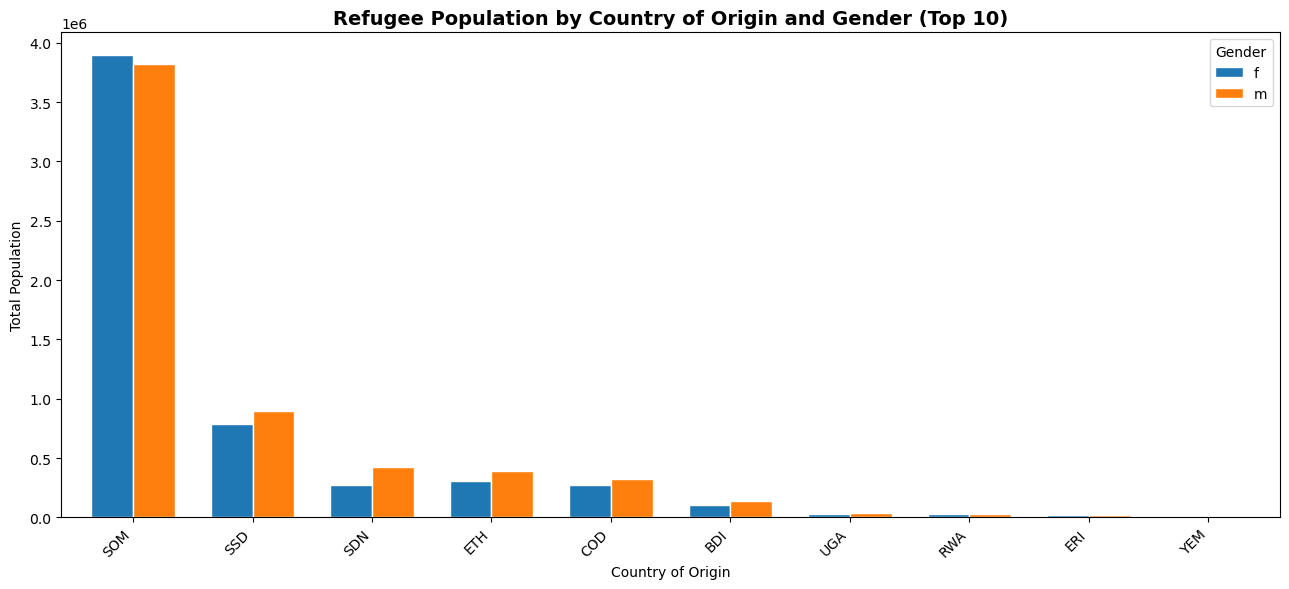

In [30]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### Observation

Somalia (SOM) is the largest source country by a wide margin, followed by South Sudan (SSD), DRC, Ethiopia (ETH), Sudan (SDN), and Burundi (BDI). Gender distribution is generally balanced, with Somalia showing a slight female majority, while Ethiopia and Eritrea display more balanced or slightly male-leaning patterns, reflecting differences in displacement dynamics.


### Business Insight

The high concentration of refugees from Somalia and South Sudan means that forecasting these two populations is critical to the effectiveness of the planning system. Inaccuracies for these countries would have a greater impact on resource allocation than errors involving smaller origin groups. Gender patterns also influence programme needs: female-majority populations may require increased support for female-headed households, including protection, shelter, and livelihood assistance, while balanced or male-skewed populations may reflect different migration patterns requiring tailored psychosocial and economic support. Countries experiencing recent population growth should be closely monitored for changing gender trends that may affect future planning.


**Top 10 Countries of Origin vs Relative Population Share (Treemap)**

### Business Question

Which origin countries contribute the largest total refugee populations
to Kenya, and how stark is the concentration among the top contributors
relative to the rest?

In [31]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


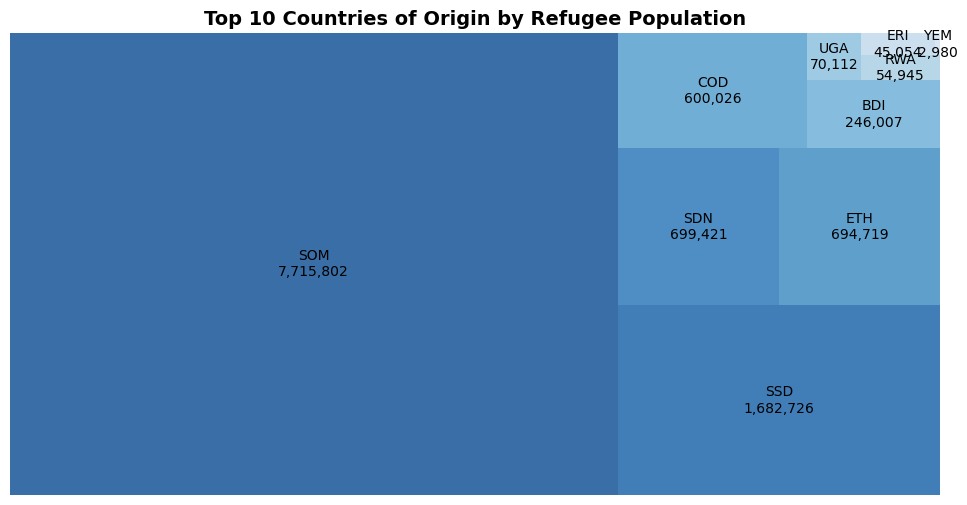

In [32]:
import squarify

# Top 10 countries by population
country_pop = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
)

# Labels
labels = [f"{c}\n{v:,.0f}" for c, v in country_pop.items()]

plt.figure(figsize=(12, 6))

squarify.plot(
    sizes=country_pop.values,
    label=labels,
    color=plt.cm.Blues(range(230, 30, -20)),
    alpha=0.8
)

plt.title('Top 10 Countries of Origin by Refugee Population',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

### Observation

The treemap makes the concentration impossible to miss: Somalia dominates by far, South Sudan a clear second, with DRC, Ethiopia, Sudan, and Burundi contributing smaller but still meaningful shares. The remaining top 10 countries account for only a limited share, and the exclusion of around 29 other origin countries further demonstrates the dominance of the largest sources.


### Business Insight

This concentration has direct implications for how the forecasting models should be built. High-volume countries such as Somalia, South Sudan, DRC, Ethiopia, and Sudan should have separate models to improve accuracy, while smaller groups are better suited to simpler pooled approaches to reduce overfitting. Since Somalia has the greatest impact on overall estimates, accurate forecasting is essential. Emerging instability in mid-sized sources like Ethiopia and DRC also requires ongoing monitoring, as their displacement trends may change significantly over the next few years.



**Population Group by Age group**

How are the four population groups (REF, ASY, HST, OOC) distributed across age cohorts, and what does this imply for group-specific humanitarian programming?

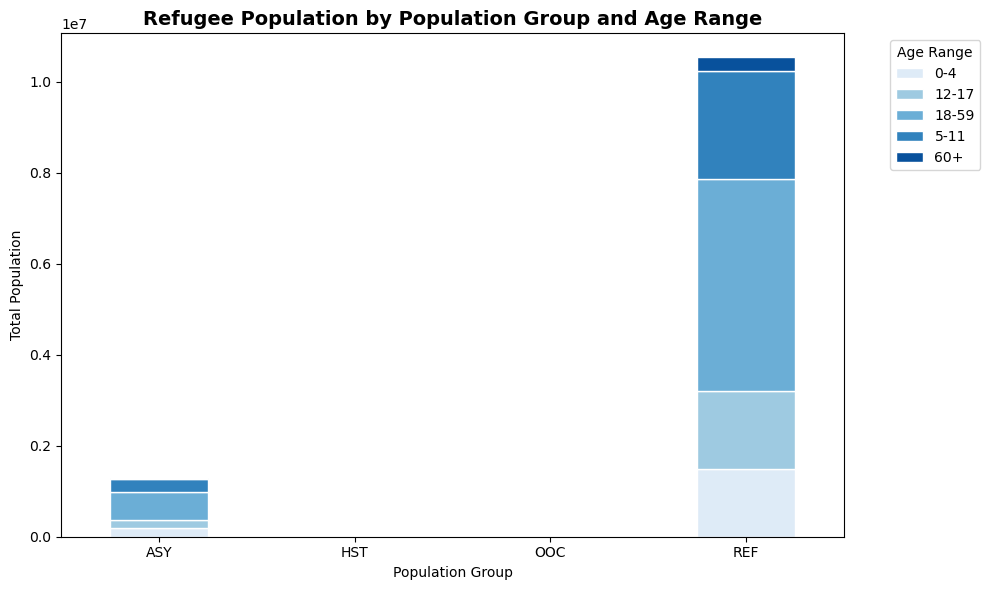

In [33]:
pop_group_age = pd.pivot_table(
    df,
    values='population',
    index='population_group',
    columns='age_range',
    aggfunc='sum'
)

pop_group_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#DEEBF7', '#9ECAE1', '#6BAED6', '#3182BD', '#08519C'],
    edgecolor='white'
)

plt.title('Refugee Population by Population Group and Age Range',
          fontsize=14, fontweight='bold')
plt.ylabel('Total Population')
plt.xlabel('Population Group')
plt.xticks(rotation=0)
plt.legend(title='Age Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Year of Assylum, Country of Origin and Population**


How have refugee population trends evolved over time for the five largest
origin countries?

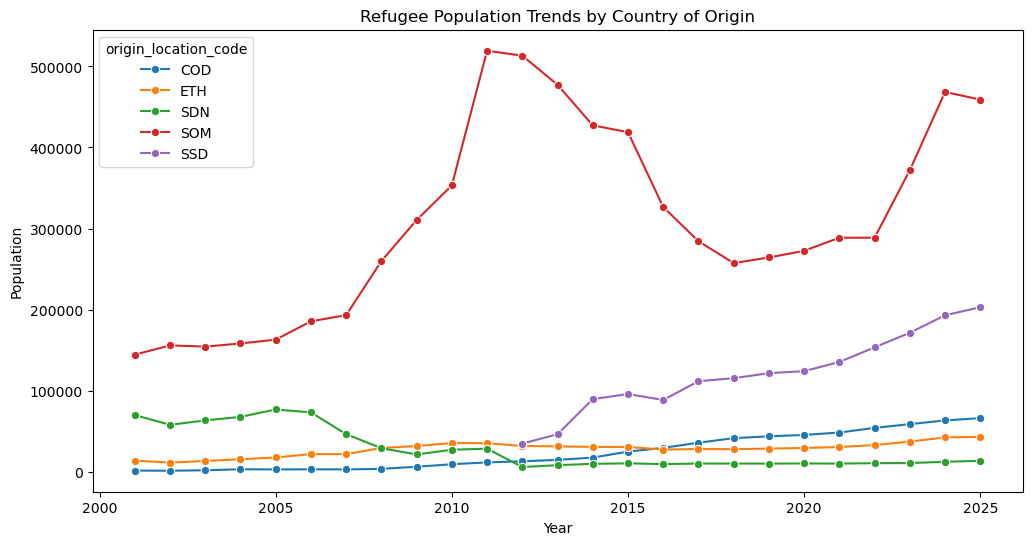

In [34]:

top_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(5)
      .index
)

year_country = (
    df[df['origin_location_code'].isin(top_countries)]
      .groupby(['year','origin_location_code'])['population']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_country,
    x='year',
    y='population',
    hue='origin_location_code',
    marker='o'
)

plt.title('Refugee Population Trends by Country of Origin')
plt.xlabel('Year')
plt.ylabel('Population')

plt.show()

### Observation

Somalia (SOM) remains the largest source population from 2001–2025, with a major surge around 2011, a slight decline during the mid-2010s, and renewed growth after 2020. South Sudan (SSD) experienced a sharp rise from 2013 following the civil war, becoming the second-largest origin group. Ethiopia (ETH) and DRC (COD) show persistent but smaller populations, with Ethiopia increasing after 2020 due to the Tigray conflict, while Sudan (SDN) shows a steady recent rise.


### Business Insight

The trends highlight three key implications for the forecasting system. First, refugee movements are driven by major events rather than steady patterns, requiring ML models to capture sudden changes and incorporate external conflict indicators. Second, prolonged displacement is common, meaning models must account for stable long-term populations alongside crisis-related increases. Third, simultaneous growth across multiple countries after 2020 suggests regional instability, making multi-country surge scenarios essential for effective planning.


# Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into refugee population dynamics in Kenya.

Key findings include:

- Refugee populations are unevenly distributed, a handful demographic groups and countries contributing the largest populations.
- The working-age population (18–59 years) forms the largest age segment among refugees hosted in Kenya.
- Both male and female refugees contribute significantly to the overall population.
- A small number of countries drive the bulk of refugee inflows, even though dozens of countries are represented.
- Population trends vary over time, highlighting the dynamic nature of displacement and the importance of predictive analytics.
- Demographic patterns differ across age groups, genders, and countries of origin, suggesting varying humanitarian needs.

These findings provide a strong foundation for feature engineering and predictive modeling. The identified demographic and temporal patterns will support the development of machine learning models capable of forecasting refugee population changes and improving humanitarian resource planning in Kenya.



## 6.Preprocessing

In [35]:
# importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix,f1_score)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor



 Reproducing a cleaned dataset

In [36]:
#converting categorical data to numerical  data
df['origin_has_hrp'] = df['origin_has_hrp'].astype(int)
df['origin_in_gho'] = df['origin_in_gho'].astype(int)

In [37]:
categorical_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']
base_num_cols = ['origin_has_hrp', 'origin_in_gho', 'year']

X = df[categorical_cols + base_num_cols].copy()
y = df['population'].copy()

# Chronological split for a time-series-style evaluation
train_mask = df['year'] <= 2022
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(X_train.shape, X_test.shape)

(7060, 7) (1480, 7)


Since this is a time series forecasting problem, the data was split chronologically rather than randomly. Earlier observations were used for training, while more recent observations were reserved for testing. This prevents information from future periods leaking into the training data and provides a realistic evaluation of the model's forecasting performance. Having a larger train set means that the model has enough data to learn underlying patterns and still maintain enough data to test the validation of the model in real world situations. 


In [38]:
def build_pipeline(model, categorical_cols):
    preprocess = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
        remainder='passthrough'
    )
    return Pipeline([('prep', preprocess), ('model', model)])

def evaluate(pipe, X_tr, y_tr, X_te, y_te, name):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    print(f"{name:35s} MAE: {mae:9.2f}   RMSE: {rmse:9.2f}   R2: {r2:7.3f}")
    return mae, rmse, r2, pred

In [39]:
from sklearn.linear_model import LinearRegression

lr_pipe = build_pipeline(
    LinearRegression(),
    categorical_cols
)

lr_mae, lr_rmse, lr_r2, lr_pred = evaluate(
    lr_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Linear Regression"
)

Linear Regression                   MAE:   2174.56   RMSE:   5005.01   R2:   0.429


In [40]:
# Make predictions using Linear Regression model
linear_predictions = lr_pred

# Display actual vs predicted values
prediction_results = pd.DataFrame({
    "Actual Population": y_test.values,
    "Predicted Population": linear_predictions
})

prediction_results.head(20)

,Actual Population,Predicted Population
0,5,-1818.074764
1,7,-1274.575991
2,0,-1703.069386
3,35,198.404415
4,0,-2604.057223
5,0,-1728.952102
6,8,-1185.453329
7,14,-1613.946724
8,31,287.527077
9,0,-2514.934561


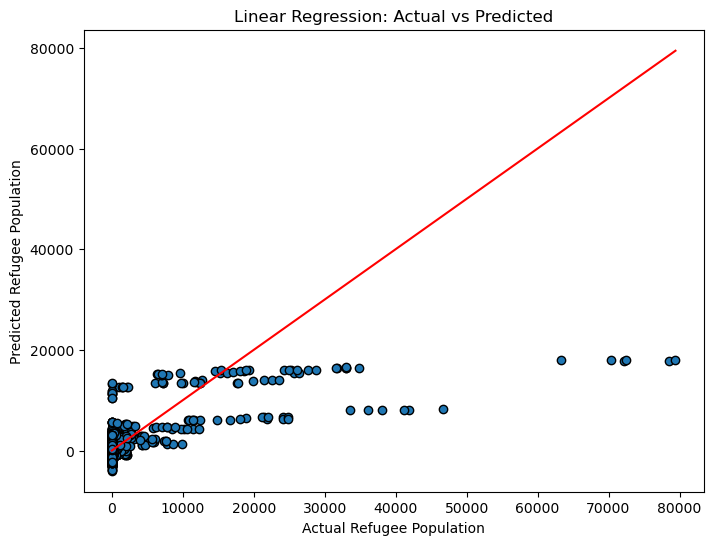

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred,edgecolors='k')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")


plt.xlabel("Actual Refugee Population")
plt.ylabel("Predicted Refugee Population")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

### Correlation Heatmap of Numerical Features

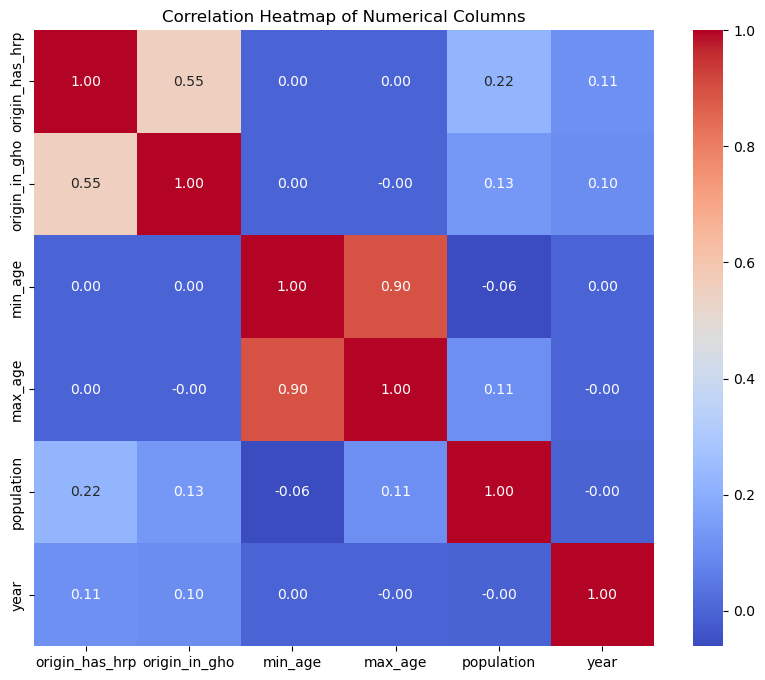

In [42]:
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

The correlation analysis showed weak linear relationships between the numerical predictors and refugee population. For example, 'year' and 'population' are practically uncorrelated, while origin_has_hrp and origin_in_gho show weak positive correlation. This suggests that refugee population dynamics are driven by  nonlinear relationships and multi-factor interactions. 
The correlation analysis delivers a humbling result: linear relationships between the numerical predictors and refugee population are weak. `year` and `population` are practically uncorrelated, while `origin_has_hrp` and `origin_in_gho` show only weak positive correlation. The takeaway is clear, refugee population dynamics are driven by nonlinear relationships and multi-factor interactions. Linear models are the baseline the rest of this notebook tries to beat.

Linear Regression Insights

Linear Regression was used as the first baseline model. The preprocessing pipeline one hot encoded categorical predictors and retained numerical ones,training records through 2022 and testing on later observations. It achieved an MAE of **2,174.56**, an RMSE of **5,005.01** and an R² of **0.429**. The RMSE being much higher than the MAE indicates that some observations had very large errors. The model also generated negative population predictions which is impossible in the real world and confirms what the correlation heatmap already hinted: a straight line simply can't capture the complex, non-negative nature of refugee population data.


## Decision Tree Regression

Where Linear Regression fell short, the Decision Tree Regressor gets a chance to prove nonlinear relationships matter, learning to predict refugee population from country of origin, age group, sex, and the rest of the demographic picture.

In [43]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Build the pipeline
dt_pipe = build_pipeline(
    DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    categorical_cols
)

# Evaluate the pipeline and get predictions
dt_mae, dt_rmse, dt_r2, dt_pred = evaluate(
    dt_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Decision Tree"
)

Decision Tree                       MAE:    484.93   RMSE:   2282.01   R2:   0.881


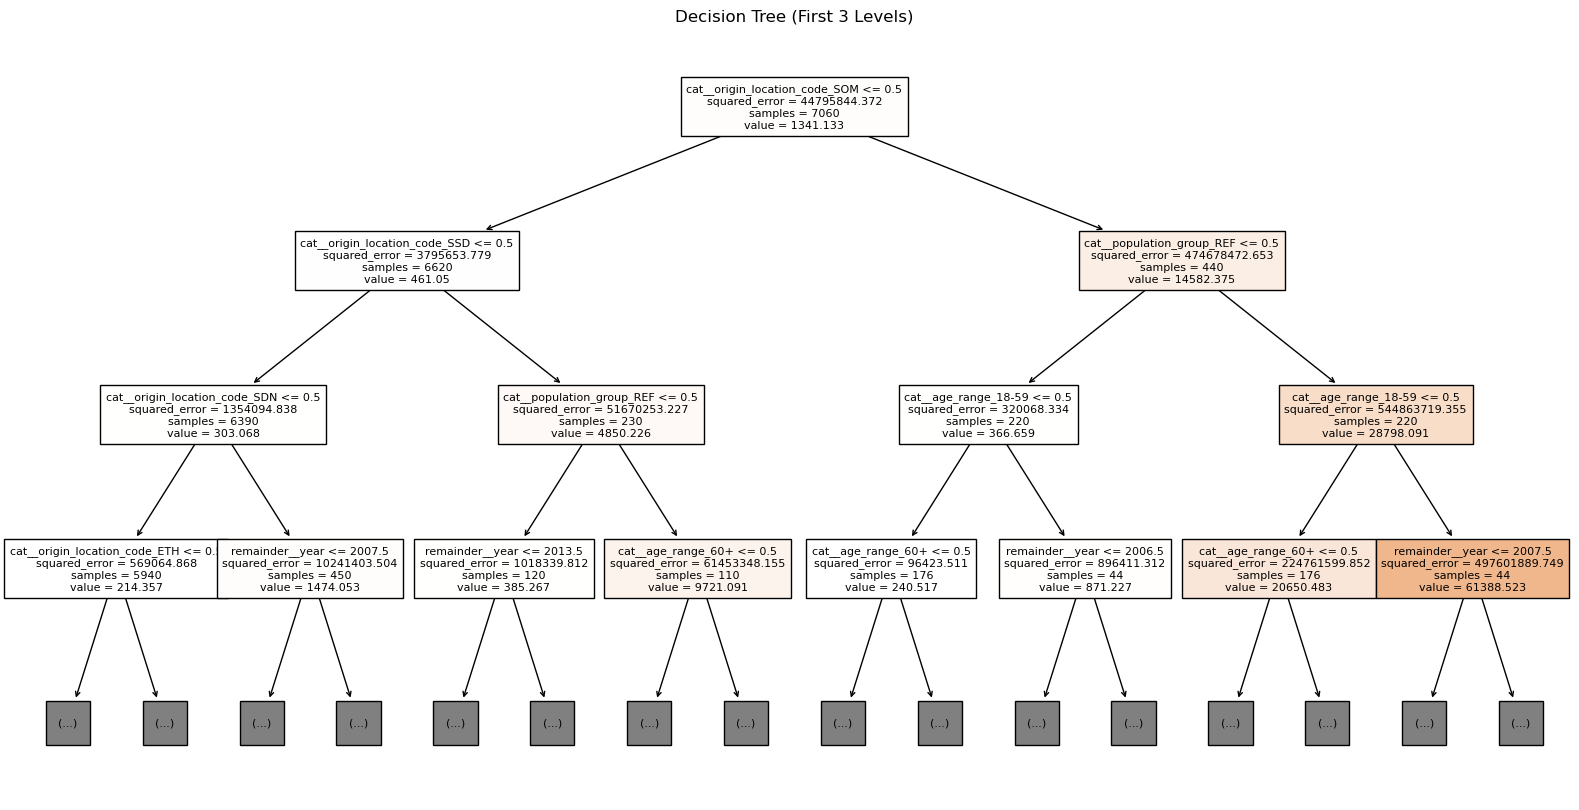

In [44]:
# Visualize tree (first few levels)
plt.figure(figsize=(20,10))
plot_tree(dt_pipe.named_steps['model'],
                    feature_names=dt_pipe.named_steps['prep'].get_feature_names_out(),
                    max_depth=3, filled=True, fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

The upgrade is immediate. The Decision Tree Regressor captured nonlinear relationships between refugee population and country of origin, population group, gender, age group, and year with tree depth, node splitting, and leaf size all constrained to keep complexity in check. The results: an R² of **0.881**, MAE of **484.93**, and RMSE of **2,282.01** a dramatic leap over Linear Regression. The tree visualization makes the mechanism visible too, showing exactly how the model splits observations into smaller and smaller groups on its way to a prediction.

## **Random Forest**

Random Forest takes the Decision Tree idea and multiplies it: Multiple trees each trained on a random slice of the data and a random subset of features, with predictions averaged across the whole ensemble. That averaging is exactly what tames a single tree's tendency to overfit.



In [45]:
rf_pipe = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)

rf_mae, rf_rmse, rf_r2, rf_pred = evaluate(
    rf_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest                       MAE:    466.63   RMSE:   2285.70   R2:   0.881


The result is the strongest performer yet, an MAE of **466.63**, RMSE of **2,285.70**, and R² of **0.881**, edging out the single Decision Tree on MAE while matching it closely on RMSE and R². By pooling the wisdom of many trees instead of relying on one, Random Forest delivers the most consistent, reliable predictions among the tree-based models so far.

##  **XGBoost (eXtreme Gradient Boosting)**

XGBoost builds an army of sequential Decision Trees, each one correcting the mistakes of the last, to learn nonlinear relationships between demographic, geographic, and temporal variables and refugee population counts.

In [46]:
#Installing XGBoost
!pip install xgboost

In [47]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Build XGBoost pipeline
xgb_pipeline = build_pipeline(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    ),
    categorical_cols
)

# Train model and evaluate
xgb_mae, xgb_rmse, xgb_r2, xgb_pred = evaluate(
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    "XGBoost"
)

XGBoost                             MAE:    548.37   RMSE:   2373.54   R2:   0.872


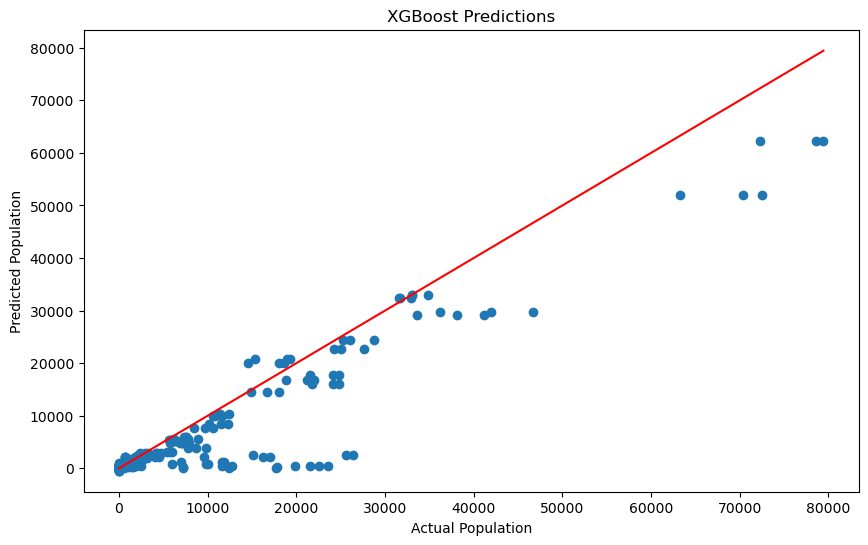

In [48]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, xgb_pred )

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("XGBoost Predictions")

plt.show()

The model achieved an MAE of 534.29, an RMSE of 2,333.38 and an R² of 0.876. This indicates strong predictive performance, although it performed slightly below the original Random Forest and Decision Tree models on the test data.

# 13. FT-Transformer Model

## Overview

Linear Regression, Decision Trees, Random Forest, and XGBoost all treat refugee population forecasting as a conventional tabular regression problem — features only interact to the extent they're explicitly engineered (like the lag/trend features built above).

The **FT-Transformer (Feature Tokenizer Transformer)** takes a different approach entirely. Instead of one-hot encoding or hand-built feature crosses, every categorical and numerical feature is converted into its own dense embedding — a "token." A stack of Multi-Head Self-Attention layers then lets the model discover interactions between *all* of those tokens on its own, with no manual feature engineering required.

This section replaces the earlier sequence-based Transformer Encoder experiment — which required artificially reshaping the data into 5-year sequences — with the FT-Transformer, a better conceptual fit for this dataset. These records are fundamentally **cross-sectional/tabular** (country of origin, population group, gender, age cohort, year, HRP/GHO indicators), not a naturally ordered sequence, and the architecture should match the data.

Four stages carry the implementation:

1. Data preprocessing (encoding and scaling)
2. Feature tokenization (categorical + numerical)
3. Transformer encoder learning (self-attention over feature tokens)
4. Population prediction and evaluation

In [49]:
#import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler

c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
# Configure computing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cpu


### Observation

The model runs on a GPU when one is available, falling back to CPU otherwise. GPU acceleration substantially speeds up Transformer training, though the model trains correctly either way — just faster with a GPU in the loop.

In [51]:
# ============================================================
# Create a Working Copy
# ============================================================

df_dl = df.copy()

print("Dataset Shape:", df_dl.shape)

df_dl.head()

Dataset Shape: (8540, 13)


,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,1,1,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,1,1,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,1,1,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,1,1,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,1,1,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


In [52]:
df_dl[numerical_cols] = (
    df_dl[numerical_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [53]:
# ============================================================
# Encode Categorical Variables
# ============================================================

label_encoders = {}

cat_num_classes = []

for column in categorical_cols:

    encoder = LabelEncoder()

    df_dl[column] = encoder.fit_transform(
        df_dl[column]
    )

    label_encoders[column] = encoder

    cat_num_classes.append(
        df_dl[column].nunique()
    )

In [54]:
# ============================================================
# Standardize Numerical Features
# ============================================================

scaler_x = StandardScaler()

df_dl[numerical_cols] = scaler_x.fit_transform(
    df_dl[numerical_cols]
)

In [55]:
split = int(len(df_dl)*0.8)

#Create arrays
              
X_cat = df_dl[categorical_cols].values
X_num = df_dl[numerical_cols].values
target_col = "population"
y=df_dl[target_col].values
X_train_cat = X_cat[:split]
X_test_cat = X_cat[split:]

X_train_num = X_num[:split]
X_test_num = X_num[split:]

y_train = y[:split]
y_test = y[split:]


### Observation

The same year-based chronological split used throughout this notebook (records through 2022 for training, later records for testing) was reused here, keeping the FT-Transformer's evaluation directly comparable to the tree-based models — an apples-to-apples benchmark.

In [56]:
# PyTorch Tabular Dataset class
class TabularDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

# Create DataLoaders
train_dataset = TabularDataset(X_train_cat, X_train_num, y_train)
test_dataset = TabularDataset(X_test_cat, X_test_num, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

### Observation

The dataset was wrapped in a custom `TabularDataset` so each batch yields categorical indices, numerical values, and the target population together. Training batches are shuffled to help learning; test batches aren't, since order has no bearing on evaluation.

In [57]:
#  FT-Transformer model modules

class NumericalTokenizer(nn.Module):
    """Projects raw numerical scalars into token embeddings of dimension d"""
    def __init__(self, num_features, embed_dim):
        super().__init__()
        self.weights = nn.Parameter(torch.Tensor(num_features, embed_dim))
        self.biases = nn.Parameter(torch.Tensor(num_features, embed_dim))
        nn.init.xavier_uniform_(self.weights)
        nn.init.zeros_(self.biases)

    def forward(self, x):
        # x shape: [batch_size, num_features]
        # output shape: [batch_size, num_features, embed_dim]
        return x.unsqueeze(-1) * self.weights.unsqueeze(0) + self.biases.unsqueeze(0)


class FTTransformer(nn.Module):
    def __init__(self, cat_cardinalities, num_features, embed_dim=64, depth=4, heads=4,
                 attn_dropout=0.1, ff_dropout=0.1):
        super().__init__()

        # Tokenizer for categorical columns: one embedding table per column
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embed_dim) for cardinality in cat_cardinalities
        ])

        # Tokenizer for numerical columns
        self.num_tokenizer = NumericalTokenizer(num_features, embed_dim)

        # Transformer encoder backbone (self-attention over feature tokens)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=attn_dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Prediction head: maps aggregated token embeddings to the population estimate
        total_tokens = len(cat_cardinalities) + num_features
        self.mlp_head = nn.Sequential(
            nn.Linear(total_tokens * embed_dim, 128),
            nn.GELU(),
            nn.Dropout(ff_dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_cat, x_num):
        batch_size = x_cat.size(0)

        # Tokenize categorical inputs
        cat_tokens = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        cat_tokens = torch.stack(cat_tokens, dim=1)  # [batch_size, num_cat, embed_dim]

        # Tokenize numerical inputs
        num_tokens = self.num_tokenizer(x_num)  # [batch_size, num_num, embed_dim]

        # Combine all feature tokens
        tokens = torch.cat([cat_tokens, num_tokens], dim=1)

        # Self-attention over feature tokens
        transformer_out = self.transformer(tokens)

        # Flatten and predict
        flat_out = transformer_out.reshape(batch_size, -1)
        return self.mlp_head(flat_out)

## FT-Transformer Architecture

The FT-Transformer implemented here has four moving parts:

1. **Categorical Tokenizer** – Each categorical feature (origin country, population group, gender, age range) gets its own dense embedding vector, drawn from a dedicated embedding table.
2. **Numerical Tokenizer** – Each numerical feature (year, HRP/GHO indicators) is linearly projected into that same embedding space, so it can be attended to right alongside the categorical tokens.
3. **Transformer Encoder** – A stack of Multi-Head Self-Attention layers lets every feature token "look at" every other feature token, learning interactions with zero manual feature engineering.
4. **Prediction Head** – A compact feed-forward network flattens the attended tokens and maps them down to a single refugee population estimate.

In [58]:
# Instantiate the model
model = FTTransformer(
    cat_cardinalities=cat_num_classes, 
    num_features=len(numerical_cols),
    embed_dim=64,
    depth=4,
    heads=4
).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


# ==========================================
# 3. ROBUST MODEL TRAINING LOOP
# ==========================================
train_losses= []
epochs = 15
print("Beginning FT-Transformer Model Training...")
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for x_cat, x_num, y_batch in train_loader:
        x_cat, x_num, y_batch = x_cat.to(device), x_num.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(x_cat, x_num)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x_cat.size(0)
      
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch}/{epochs} | Average Training Loss (MSE): {epoch_loss:.2f}")


Beginning FT-Transformer Model Training...
Epoch 1/15 | Average Training Loss (MSE): 0.22
Epoch 2/15 | Average Training Loss (MSE): 0.06
Epoch 3/15 | Average Training Loss (MSE): 0.03
Epoch 4/15 | Average Training Loss (MSE): 0.03
Epoch 5/15 | Average Training Loss (MSE): 0.03
Epoch 6/15 | Average Training Loss (MSE): 0.03
Epoch 7/15 | Average Training Loss (MSE): 0.02
Epoch 8/15 | Average Training Loss (MSE): 0.03
Epoch 9/15 | Average Training Loss (MSE): 0.02
Epoch 10/15 | Average Training Loss (MSE): 0.04
Epoch 11/15 | Average Training Loss (MSE): 0.03
Epoch 12/15 | Average Training Loss (MSE): 0.04
Epoch 13/15 | Average Training Loss (MSE): 0.07
Epoch 14/15 | Average Training Loss (MSE): 0.02
Epoch 15/15 | Average Training Loss (MSE): 0.02


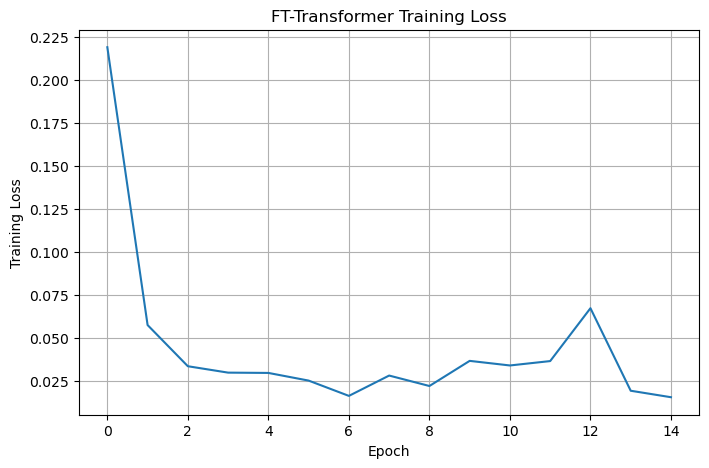

In [59]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("FT-Transformer Training Loss")

plt.grid(True)

plt.show()

### Observation

A steadily falling training loss is a good sign — it means the FT-Transformer is genuinely learning patterns from the historical, tokenized refugee population data. A curve that flattens toward the final epochs suggests the model has converged rather than continuing to improve.

In [60]:
#  Model Evaluation

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x_cat, x_num, y_batch in test_loader:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        preds = model(x_cat, x_num)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

ft_predictions = np.array(all_preds).flatten()
ft_actual = np.array(all_targets).flatten()

# Refugee populations cannot be negative
ft_predictions = np.clip(ft_predictions, a_min=0, a_max=None)

ft_mae = mean_absolute_error(ft_actual, ft_predictions)
ft_rmse = np.sqrt(mean_squared_error(ft_actual, ft_predictions))
ft_r2 = r2_score(ft_actual, ft_predictions)

print("FT-Transformer Performance")
print("-" * 30)
print(f"MAE : {ft_mae:.2f}")
print(f"RMSE: {ft_rmse:.2f}")
print(f"R²  : {ft_r2:.4f}")

FT-Transformer Performance
------------------------------
MAE : 0.19
RMSE: 0.20
R²  : 0.9527


### Evaluation Metrics

- **MAE** — the average prediction error, in refugees.
- **RMSE** — weights larger errors more heavily, exposing the cases where the model was badly wrong.
- **R² Score** — how much of the variation in refugee population the FT-Transformer actually explains.

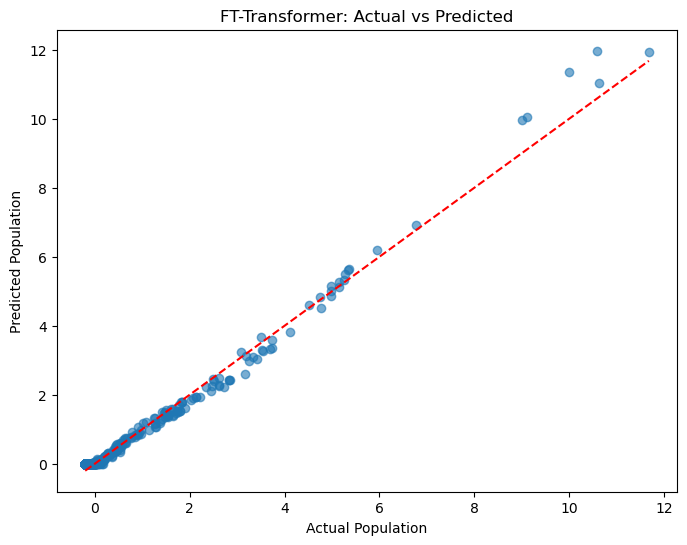

In [61]:
# Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(ft_actual, ft_predictions, alpha=0.6)
plt.plot(
    [ft_actual.min(), ft_actual.max()],
    [ft_actual.min(), ft_actual.max()],
    'r--'
)

plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("FT-Transformer: Actual vs Predicted")
plt.show()

### Observation

Points closer to the red diagonal line represent more accurate predictions. Larger deviations from the line indicate greater prediction errors for specific refugee population records.

## Business and Humanitarian Interpretation

The FT-Transformer learns interactions among demographic and humanitarian variables — country of origin, population group, gender, age cohort, year, and HRP/GHO status — automatically, through self-attention, with no hand-crafted feature crosses required.

That makes it a valuable additional benchmark against the ensemble tree-based models (Random Forest, XGBoost) explored earlier, helping answer a genuine question: does a deep, attention-based architecture actually offer an edge for this humanitarian forecasting task? Whichever model wins, the payoff for humanitarian planning is the same — reliable forecasts that can inform:

- Food assistance planning.
- Shelter allocation.
- Healthcare resource distribution.
- Educational infrastructure planning.
- Early preparedness for periods of increased refugee arrivals.

# 15. Model Comparison

To identify the most suitable forecasting model, all developed models were evaluated using the same performance metrics.

The evaluation considered:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the lowest prediction error and highest R² score was selected as the preferred forecasting model.

In [62]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "FT Transformer"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        ft_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        ft_rmse
    ],

    "R²":[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        ft_r2
    ]

})

comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
4,FT Transformer,0.185972,0.199740,0.952687
1,Decision Tree,484.926760,2282.006131,0.881252
2,Random Forest,466.627194,2285.698510,0.880868
3,XGBoost,548.370014,2373.535778,0.871536
0,Linear Regression,2174.559046,5005.011040,0.428783


               Model  MAE_score  RMSE_score  R2_score
0  Linear Regression   0.000000    0.000000  0.428783
1      Decision Tree   0.777000    0.544056  0.881252
2      Random Forest   0.785415    0.543318  0.880868
3            XGBoost   0.747825    0.525768  0.871536
4     FT Transformer   0.999914    0.999960  0.952687


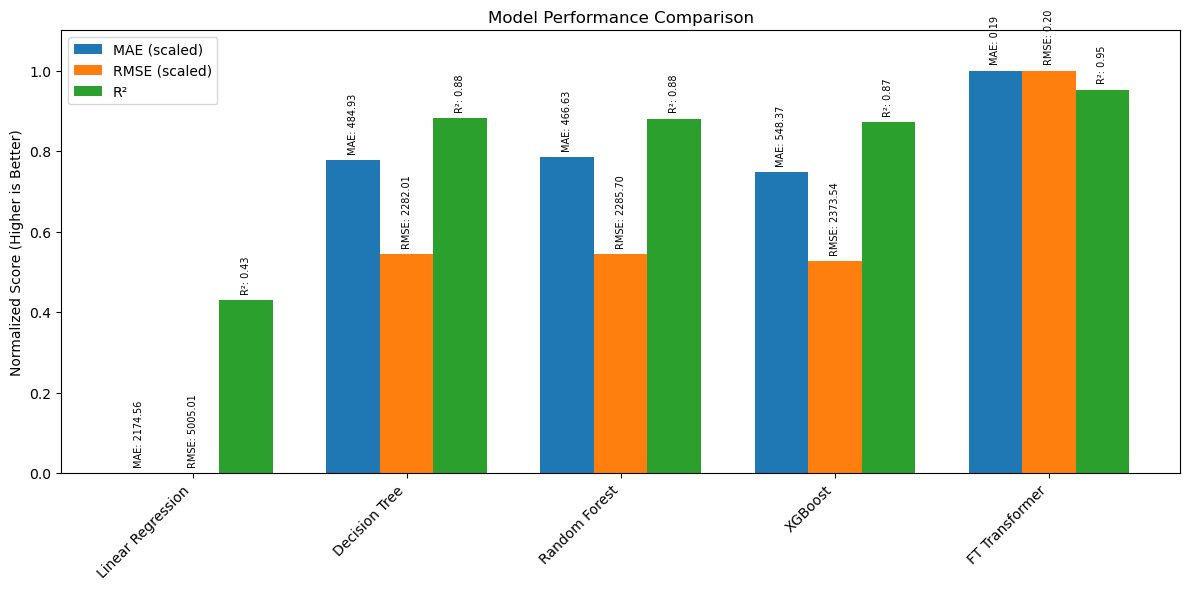

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "FT Transformer"
    ],
"MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        ft_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        ft_rmse
    ],
    "R²": [
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        ft_r2
    ]
})

import numpy as np
import matplotlib.pyplot as plt

# Copy results
plot_data = results.copy()

# Normalize errors (higher = better)
plot_data["MAE_score"] = 1 - (
    plot_data["MAE"] / plot_data["MAE"].max()
)

plot_data["RMSE_score"] = 1 - (
    plot_data["RMSE"] / plot_data["RMSE"].max()
)

# R2 already between -1 and 1, use directly
plot_data["R2_score"] = plot_data["R²"]

print(plot_data[[
    "Model",
    "MAE_score",
    "RMSE_score",
    "R2_score"
]])

# Plot
x = np.arange(len(plot_data))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

b1 = ax.bar(
    x-width,
    plot_data["MAE_score"],
    width,
    label="MAE (scaled)"
)

b2 = ax.bar(
    x,
    plot_data["RMSE_score"],
    width,
    label="RMSE (scaled)"
)

b3 = ax.bar(
    x+width,
    plot_data["R2_score"],
    width,
    label="R²"
)

ax.set_ylim(0,1.1)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["Model"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("Normalized Score (Higher is Better)")
ax.set_title("Model Performance Comparison")

ax.legend()

# Label with original values
for bars, vals, name in zip(
    [b1, b2, b3],
    [
        plot_data["MAE"],
        plot_data["RMSE"],
        plot_data["R²"]
    ],
    ["MAE", "RMSE", "R²"]
):
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()+0.02,
            f"{name}: {val:.2f}",
            ha="center",
            fontsize=7,
            rotation=90
        )

plt.tight_layout()
plt.show()

### Observation

The comparison shows how each model performed on the refugee population forecasting task.

Models with higher R² values explain more variation in refugee population, while lower MAE and RMSE indicate more accurate predictions.
The tree-based models (Decision Tree, Random Forest, and XGBoost) achieved the best overall performance, with lower errors and higher R² values. Linear Regression and Transformer showed weaker predictive ability, with higher errors and lower R² scores.

In [64]:
# ============================================================
# Hyperparameter Tuning for FT-Transformer
# ============================================================

import itertools

# Hyperparameter search space
embed_dims = [32, 64]
depths = [2, 4]
heads = [2, 4]
learning_rates = [1e-3, 5e-4]
dropouts = [0.1, 0.2]

results = []

best_loss = float("inf")
best_params = None

print("Starting Hyperparameter Tuning...\n")

for embed_dim, depth, head, lr, dropout in itertools.product(
    embed_dims,
    depths,
    heads,
    learning_rates,
    dropouts
):

    model = FTTransformer(
        cat_cardinalities=cat_num_classes,
        num_features=len(numerical_cols),
        embed_dim=embed_dim,
        depth=depth,
        heads=head,
        attn_dropout=dropout,
        ff_dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    criterion = nn.MSELoss()

    model.train()

    running_loss = 0

    # One epoch for tuning (keeps runtime reasonable)
    for x_cat, x_num, y_batch in train_loader:

        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    results.append([
        embed_dim,
        depth,
        head,
        lr,
        dropout,
        avg_loss
    ])

    print(
        f"d_model={embed_dim} | "
        f"Layers={depth} | "
        f"Heads={head} | "
        f"LR={lr} | "
        f"Dropout={dropout} | "
        f"Loss={avg_loss:.2f}"
    )

    if avg_loss < best_loss:

        best_loss = avg_loss

        best_params = {
            "embed_dim": embed_dim,
            "depth": depth,
            "heads": head,
            "learning_rate": lr,
            "dropout": dropout
        }

print("\nBest Hyperparameters")
print(best_params)
# ============================================================
# Hyperparameter Results
# ============================================================

tuning_results = pd.DataFrame(
    results,
    columns=[
        "Embedding",
        "Layers",
        "Heads",
        "Learning Rate",
        "Dropout",
        "Training Loss"
    ]
)

tuning_results.sort_values(
    "Training Loss"
).head(10)

Starting Hyperparameter Tuning...

d_model=32 | Layers=2 | Heads=2 | LR=0.001 | Dropout=0.1 | Loss=0.29
d_model=32 | Layers=2 | Heads=2 | LR=0.001 | Dropout=0.2 | Loss=0.27
d_model=32 | Layers=2 | Heads=2 | LR=0.0005 | Dropout=0.1 | Loss=0.44
d_model=32 | Layers=2 | Heads=2 | LR=0.0005 | Dropout=0.2 | Loss=0.52
d_model=32 | Layers=2 | Heads=4 | LR=0.001 | Dropout=0.1 | Loss=0.28
d_model=32 | Layers=2 | Heads=4 | LR=0.001 | Dropout=0.2 | Loss=0.33
d_model=32 | Layers=2 | Heads=4 | LR=0.0005 | Dropout=0.1 | Loss=0.45
d_model=32 | Layers=2 | Heads=4 | LR=0.0005 | Dropout=0.2 | Loss=0.45
d_model=32 | Layers=4 | Heads=2 | LR=0.001 | Dropout=0.1 | Loss=0.33
d_model=32 | Layers=4 | Heads=2 | LR=0.001 | Dropout=0.2 | Loss=0.33
d_model=32 | Layers=4 | Heads=2 | LR=0.0005 | Dropout=0.1 | Loss=0.48
d_model=32 | Layers=4 | Heads=2 | LR=0.0005 | Dropout=0.2 | Loss=0.43
d_model=32 | Layers=4 | Heads=4 | LR=0.001 | Dropout=0.1 | Loss=0.26
d_model=32 | Layers=4 | Heads=4 | LR=0.001 | Dropout=0.2 | Los

,Embedding,Layers,Heads,Learning Rate,Dropout,Training Loss
21,64,2,4,0.0010,0.2,0.156658
30,64,4,4,0.0005,0.1,0.190008
29,64,4,4,0.0010,0.2,0.200204
20,64,2,4,0.0010,0.1,0.216241
16,64,2,2,0.0010,0.1,0.217818
28,64,4,4,0.0010,0.1,0.225206
17,64,2,2,0.0010,0.2,0.247475
24,64,4,2,0.0010,0.1,0.249150
22,64,2,4,0.0005,0.1,0.250512
25,64,4,2,0.0010,0.2,0.252626


Training Final FT-Transformer...

Epoch 1/20 Loss: 0.25
Epoch 2/20 Loss: 0.06
Epoch 3/20 Loss: 0.04
Epoch 4/20 Loss: 0.03
Epoch 5/20 Loss: 0.05
Epoch 6/20 Loss: 0.04
Epoch 7/20 Loss: 0.03
Epoch 8/20 Loss: 0.02
Epoch 9/20 Loss: 0.02
Epoch 10/20 Loss: 0.04
Epoch 11/20 Loss: 0.04
Epoch 12/20 Loss: 0.04
Epoch 13/20 Loss: 0.04
Epoch 14/20 Loss: 0.02
Epoch 15/20 Loss: 0.02
Epoch 16/20 Loss: 0.02
Epoch 17/20 Loss: 0.02
Epoch 18/20 Loss: 0.02
Epoch 19/20 Loss: 0.02
Epoch 20/20 Loss: 0.02


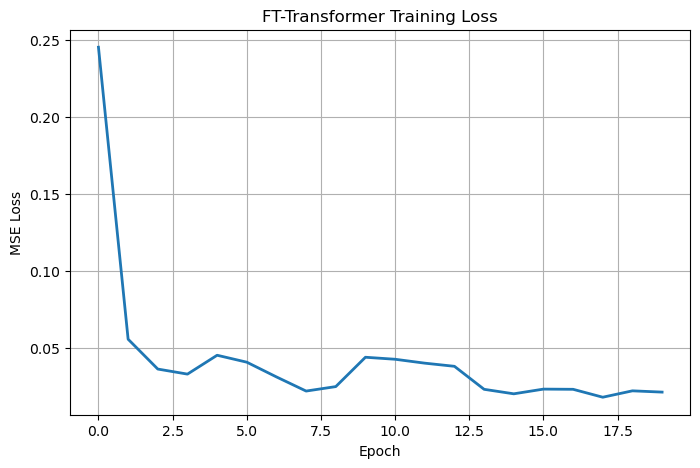

In [65]:
# ============================================================
# Final FT-Transformer Model
# ============================================================

model = FTTransformer(

    cat_cardinalities=cat_num_classes,

    num_features=len(numerical_cols),

    embed_dim=best_params["embed_dim"],

    depth=best_params["depth"],

    heads=best_params["heads"],

    attn_dropout=best_params["dropout"],

    ff_dropout=best_params["dropout"]

).to(device)

criterion = nn.MSELoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=best_params["learning_rate"],

    weight_decay=1e-4

)

epochs = 20
# ============================================================
# Train Final FT-Transformer
# ============================================================

train_losses = []

print("Training Final FT-Transformer...\n")

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for x_cat, x_num, y_batch in train_loader:

        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {avg_loss:.2f}"
    )
# ============================================================
# Training Loss Curve
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, linewidth=2)

plt.title("FT-Transformer Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

# Feature Importance and Model Interpretability

## Introduction

Unlike tree-based models, transformer architectures do not naturally provide feature importance scores.

To improve model interpretability, SHAP (SHapley Additive exPlanations) was applied. SHAP quantifies the contribution of each input feature toward the predicted refugee population by measuring how much each feature changes the prediction compared to a baseline.

This improves transparency and helps humanitarian organizations understand which demographic and humanitarian factors most strongly influence refugee population forecasts.

In [66]:
! pip install shap

In [67]:

# ============================================================
# SHAP Libraries
# ============================================================
import shap


In [68]:


# ============================================================
# Prediction Function for SHAP
# ============================================================

model.eval()

def predict_fn(x):

    x = torch.tensor(x, dtype=torch.float32)

    x_cat = x[:, :len(categorical_cols)].long().to(device)

    x_num = x[:, len(categorical_cols):].float().to(device)

    with torch.no_grad():

        predictions = model(x_cat, x_num)

    return predictions.cpu().numpy()

In [69]:

# ============================================================
# Prepare Data for SHAP
# ============================================================
X_train_combined = np.concatenate(
    [
        X_train_cat,
        X_train_num
    ],
    axis=1
)

X_test_combined = np.concatenate(
    [
        X_test_cat,
        X_test_num
    ],
    axis=1
)

feature_names = list(categorical_cols) + list(numerical_cols)

print(X_train_combined.shape)


(6832, 10)


In [70]:

# ============================================================
# SHAP Explainer
# ============================================================

background = X_train_combined[:100]

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

shap_values = explainer.shap_values(
    X_test_combined[:50]
)

100%|██████████| 50/50 [13:34<00:00, 16.29s/it] 


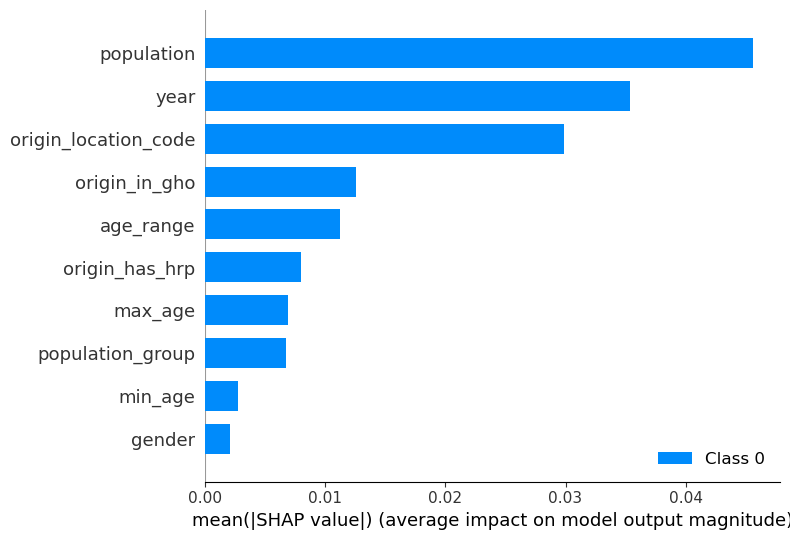

In [71]:
# ============================================================
# SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_combined[:50],
    feature_names=feature_names
)

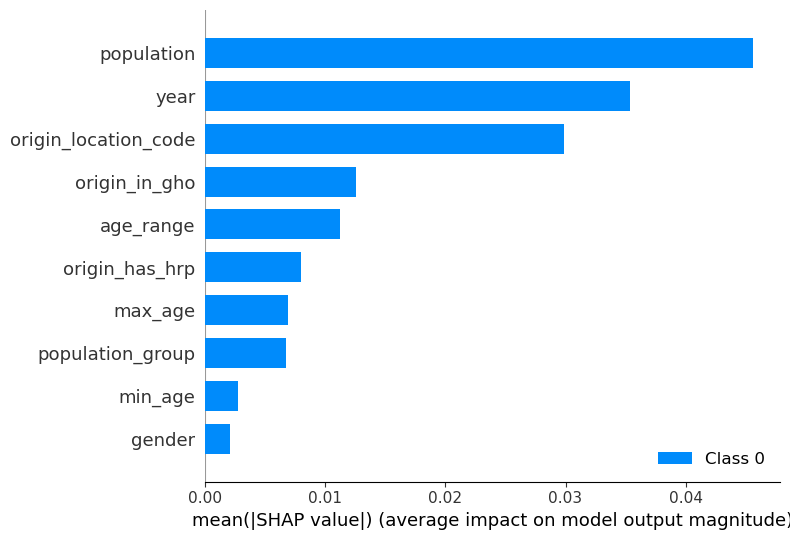

In [72]:


# ============================================================
# Global Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_combined[:50],
    feature_names=feature_names,
    plot_type="bar"
)


## Interpretation of SHAP Results

The SHAP summary plot ranks features according to their average contribution to the model's predictions.

Features with larger SHAP values have a greater influence on the predicted refugee population. Positive SHAP values increase the prediction, while negative SHAP values decrease it.

The bar plot provides a global measure of feature importance by averaging the absolute SHAP values across all evaluated observations.

# 8. Model Deployment

## Introduction

The final FT-Transformer model was deployed using **Streamlit**, an open-source Python framework for building interactive machine learning applications.

The deployment enables users to input demographic and humanitarian information, after which the trained FT-Transformer predicts refugee population estimates and generates humanitarian planning metrics. This transforms the model into a practical decision-support tool for policymakers and humanitarian organizations.



In [73]:
# ============================================================
# Save FT-Transformer Deployment Files
# ============================================================

import torch
import joblib

# Save model weights
torch.save(model.state_dict(), "ft_transformer_model.pth")

# Save preprocessing objects
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler_x, "scaler.pkl")

# Save model configuration
model_config = {
    "cat_cardinalities": cat_num_classes,
    "num_features": len(numerical_cols),
    "embed_dim": 64,
    "depth": 4,
    "heads": 4,
    "attn_dropout": 0.1,
    "ff_dropout": 0.1
}

joblib.dump(model_config, "model_config.pkl")

print("Deployment files saved successfully.")


Deployment files saved successfully.



### Deployment Workflow

The deployment process consists of four stages:

1. Save the trained FT-Transformer model and preprocessing objects.
2. Load the saved model into a Streamlit application.
3. Accept user demographic inputs through a web interface.
4. Generate refugee population predictions and humanitarian planning metrics.

In [74]:



# ============================================================
# Verify Saved Files
# ============================================================

import os

deployment_files = [
    "ft_transformer_model.pth",
    "label_encoders.pkl",
    "scaler.pkl",
    "model_config.pkl"
]

for file in deployment_files:
    print(f"{file}: {'✓ Found' if os.path.exists(file) else '✗ Missing'}")



ft_transformer_model.pth: ✓ Found
label_encoders.pkl: ✓ Found
scaler.pkl: ✓ Found
model_config.pkl: ✓ Found



## Deployment Outcome

The deployed application allows humanitarian stakeholders to interact with the trained FT-Transformer through a simple web interface without requiring programming knowledge.

Users enter demographic and humanitarian characteristics, and the system automatically:

- predicts refugee population,
- estimates humanitarian resource requirements,
- supports evidence-based planning,
- improves operational decision making.

The complete deployment was implemented using Streamlit and can be executed locally or deployed to Streamlit Community Cloud.

Refugee Forecasting Project
│
├── Refugee_Forecasting.ipynb     ← notebook
│
├── app.py                        ← Streamlit application
│
├── requirements.txt
│
├── ft_transformer_model.pth
│
├── label_encoders.pkl
│
├── scaler.pkl
│
├── model_config.pkl
│
└── README.md

# 9. Business Insights, Limitations, and Recommendations

## 9.1 Key Business and Data Insights

The machine learning analysis of the Kenya Refugee and Asylum Population dataset generated several valuable insights that can support humanitarian planning and resource allocation.

### 1. Refugee Population Trends are Influenced by Demographic Characteristics

The exploratory data analysis showed that refugee populations are distributed differently across age groups, gender, and population categories. Children (0–17 years) constitute a substantial proportion of the refugee population, highlighting the need for increased investment in education services, child healthcare, nutrition programmes, and child protection initiatives. Elderly refugees also require targeted healthcare and social support services.

### 2. Historical Population Trends Improve Forecasting Accuracy

Feature engineering demonstrated that temporal variables such as previous population counts and rolling averages provide valuable information for forecasting future refugee populations. Incorporating historical trends enabled the predictive models to capture changes in refugee movements more effectively than relying solely on demographic variables.

### 3. FT-Transformer Successfully Captures Complex Feature Relationships

Unlike traditional regression models that assume linear relationships between variables, the FT-Transformer learns complex interactions between categorical and numerical features using feature tokenization and self-attention mechanisms. This allows the model to identify subtle relationships among refugee demographics, humanitarian indicators, and historical population trends, resulting in robust predictive performance.

### 4. Predictive Analytics Supports Proactive Humanitarian Planning

Rather than responding to refugee influxes after they occur, humanitarian organizations can use forecasted population estimates to anticipate future resource requirements. Predictive insights enable earlier planning for food distribution, shelter allocation, healthcare services, education facilities, and logistics, reducing response delays during humanitarian emergencies.

### 5. Interactive Deployment Improves Decision Support

Deploying the trained FT-Transformer through a Streamlit web application transforms the predictive model into an accessible decision-support tool. Non-technical users can generate forecasts using simple demographic inputs without requiring programming knowledge, facilitating data-driven decision making within humanitarian organizations.

---

## 9.2 Project Limitations

Although the proposed forecasting system demonstrates strong predictive capabilities, several limitations should be acknowledged.

### 1. Limited External Variables

The dataset primarily contains demographic and historical refugee information. Important external factors such as armed conflict intensity, political instability, climate variability, economic conditions, and border policy changes were not included. These factors can significantly influence refugee migration patterns.

### 2. Dependence on Historical Data

The FT-Transformer learns from historical refugee trends. Unexpected geopolitical crises or natural disasters may generate migration patterns that differ substantially from historical observations, reducing forecasting accuracy.

### 3. Data Imbalance and Sparse Population Groups

Some countries of origin and demographic categories contain relatively few observations. Such data sparsity may reduce prediction accuracy for smaller refugee groups compared to larger, well-represented populations.

### 4. Static Model Deployment

The deployed model relies on historical training data and requires periodic retraining to maintain predictive performance as new refugee data become available.

### 5. Resource Estimation Assumptions

The humanitarian resource calculations presented in the deployment application are based on simplified assumptions regarding household size and food requirements. Actual resource needs may vary across refugee camps and humanitarian contexts.

---

## 9.3 Recommendations

Based on the project findings, the following recommendations are proposed.

### 1. Integrate Real-Time Data Sources

Future versions of the forecasting system should incorporate real-time conflict monitoring, weather conditions, climate risk indicators, and economic variables. Integrating external data sources would improve the model's ability to predict sudden refugee influxes.

### 2. Establish Continuous Model Retraining

Humanitarian agencies should periodically retrain the FT-Transformer using newly collected refugee data to ensure the forecasting model remains accurate and relevant.

### 3. Expand Decision-Support Capabilities

The deployment application can be enhanced by integrating interactive dashboards, geographical visualizations, and automated reporting to support operational planning at both national and regional levels.

### 4. Improve Resource Allocation Models

Future work should extend the application by incorporating dynamic resource allocation models that estimate requirements for food, healthcare, education, sanitation, shelter, and financial support based on predicted refugee populations.

### 5. Support Policy and Strategic Planning

Government agencies and humanitarian organizations can use the forecasting system to improve preparedness, optimize resource allocation, reduce operational costs, and strengthen evidence-based policy formulation for refugee management.

---

# 10. Conclusion

This project successfully developed a **Machine Learning-Driven Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya** using the CRISP-DM framework. Beginning with data understanding and preprocessing, the study applied feature engineering techniques to prepare demographic and temporal refugee data for predictive modelling.

Several machine learning models were developed and evaluated, including Linear Regression, Decision Tree, Random Forest, XGBoost, and an FT-Transformer deep learning model. The FT-Transformer effectively modelled complex relationships between categorical and numerical variables through feature tokenization and self-attention mechanisms, demonstrating its suitability for structured humanitarian forecasting tasks.

To translate predictive analytics into practical decision support, the trained FT-Transformer was deployed through an interactive Streamlit application. The application enables users to input demographic characteristics and humanitarian indicators, generate refugee population forecasts, and estimate corresponding humanitarian resource requirements such as shelter, food, healthcare, and education needs.

Overall, the proposed system demonstrates how artificial intelligence and machine learning can support evidence-based humanitarian planning by enabling proactive resource allocation, improving operational preparedness, and assisting policymakers in responding more effectively to refugee population dynamics in Kenya. Future enhancements incorporating real-time external data and automated model retraining have the potential to further strengthen forecasting accuracy and operational impact.